# AQI Analysis of Delhi

### Prepared By
**Dommeti Venkata Ramana**

### Internship Project Report

## Project Objective

To analyze Delhi air quality data and identify pollution patterns, relationships among pollutants, and major air-quality trends using statistical analysis and visualization techniques.

## 1. Introduction

Air pollution is one of the most significant environmental challenges faced by urban areas worldwide. Delhi, the capital city of India, frequently experiences poor air quality due to factors such as vehicular emissions, industrial activities, construction dust, and seasonal weather conditions.

This project aims to analyze Delhi's Air Quality Index (AQI) data by examining the concentration levels of various pollutants, identifying trends, understanding relationships among pollutants, and extracting meaningful insights through statistical analysis and visualization techniques.

The analysis focuses on major pollutants including Carbon Monoxide (CO), Nitric Oxide (NO), Nitrogen Dioxide (NO₂), Ozone (O₃), Sulfur Dioxide (SO₂), Ammonia (NH₃), PM2.5, and PM10.

## 2. Research Questions

1. Which pollutant has the highest average concentration in Delhi?

2. What are the distributions of PM2.5 and PM10 levels?

3. Is there a strong relationship between PM2.5 and PM10 concentrations?

4. Which pollutants show the highest variability over time?

5. Are there significant outliers in pollutant concentrations?

6. How do pollutant levels change over time?

7. Which pollutants are most strongly correlated with each other?

8. What are the top pollution events recorded in the dataset?

9. What insights can be derived from the statistical summary of pollutant data?

10. What recommendations can be suggested based on the observed pollution patterns?

## 3. Dataset Overview

The dataset contains air quality measurements collected in Delhi. It includes concentrations of major air pollutants such as Carbon Monoxide (CO), Nitric Oxide (NO), Nitrogen Dioxide (NO₂), Ozone (O₃), Sulfur Dioxide (SO₂), PM2.5, PM10, and Ammonia (NH₃).

Dataset Information:
- Total Records: 561
- Total Features: 9
- Time Period: January 2023
- Data Type: Time-Series Environmental Data

Columns:
- date : Observation timestamp
- co : Carbon Monoxide
- no : Nitric Oxide
- no2 : Nitrogen Dioxide
- o3 : Ozone
- so2 : Sulfur Dioxide
- pm2_5 : Fine Particulate Matter (PM2.5)
- pm10 : Particulate Matter (PM10)
- nh3 : Ammonia

## 4. Data Loading

In this section, the AQI dataset is loaded into a Pandas DataFrame. Initial inspection is performed to understand the structure, dimensions, and sample records of the dataset.


In [3]:
import pandas as pd

df = pd.read_csv("delhiaqi.csv")

print("Shape:", df.shape)
df.head()

Shape: (561, 9)


,date,co,no,no2,o3,so2,pm2_5,pm10,nh3
0,2023-01-01 00:00:00,1655.58,1.66,39.41,5.90,17.88,169.29,194.64,5.83
1,2023-01-01 01:00:00,1869.20,6.82,42.16,1.99,22.17,182.84,211.08,7.66
2,2023-01-01 02:00:00,2510.07,27.72,43.87,0.02,30.04,220.25,260.68,11.40
3,2023-01-01 03:00:00,3150.94,55.43,44.55,0.85,35.76,252.90,304.12,13.55
4,2023-01-01 04:00:00,3471.37,68.84,45.24,5.45,39.10,266.36,322.80,14.19


In [4]:
def aqi_pm25(c):
    bp = [(0,30,0,50),(30,60,51,100),(60,90,101,200),
          (90,120,201,300),(120,250,301,400),(250,500,401,500)]
    for lo,hi,alo,ahi in bp:
        if c<=hi: return alo+(ahi-alo)*(c-lo)/(hi-lo)
    return 500

def aqi_pm10(c):
    bp = [(0,50,0,50),(50,100,51,100),(100,250,101,200),
          (250,350,201,300),(350,430,301,400),(430,600,401,500)]
    for lo,hi,alo,ahi in bp:
        if c<=hi: return alo+(ahi-alo)*(c-lo)/(hi-lo)
    return 500

df['AQI'] = df[['pm2_5','pm10']].apply(
    lambda r: max(aqi_pm25(r['pm2_5']), aqi_pm10(r['pm10'])), axis=1)

def aqi_category(v):
    if v<=50: return 'Good'
    if v<=100: return 'Satisfactory'
    if v<=200: return 'Moderate'
    if v<=300: return 'Poor'
    if v<=400: return 'Very Poor'
    return 'Severe'

df['AQI_Category'] = df['AQI'].apply(aqi_category)
print(df[['date','AQI','AQI_Category']].head(10))

                  date         AQI AQI_Category
0  2023-01-01 00:00:00  338.536231    Very Poor
1  2023-01-01 01:00:00  348.855077    Very Poor
2  2023-01-01 02:00:00  377.344231    Very Poor
3  2023-01-01 03:00:00  402.148400       Severe
4  2023-01-01 04:00:00  407.478560       Severe
5  2023-01-01 05:00:00  411.509840       Severe
6  2023-01-01 06:00:00  418.978400       Severe
7  2023-01-01 07:00:00  330.570538    Very Poor
8  2023-01-01 08:00:00  311.958538    Very Poor
9  2023-01-01 09:00:00  311.067538    Very Poor


## 5. Data Understanding

This section explores the dataset structure, data types, statistical summary, and missing values. Understanding the dataset helps identify potential data quality issues and prepares the data for further analysis.

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 561 entries, 0 to 560
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   date          561 non-null    str    
 1   co            561 non-null    float64
 2   no            561 non-null    float64
 3   no2           561 non-null    float64
 4   o3            561 non-null    float64
 5   so2           561 non-null    float64
 6   pm2_5         561 non-null    float64
 7   pm10          561 non-null    float64
 8   nh3           561 non-null    float64
 9   AQI           561 non-null    float64
 10  AQI_Category  561 non-null    str    
dtypes: float64(9), str(2)
memory usage: 48.3 KB


In [6]:
df['date'] = pd.to_datetime(df['date'])

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 561 entries, 0 to 560
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   date          561 non-null    datetime64[us]
 1   co            561 non-null    float64       
 2   no            561 non-null    float64       
 3   no2           561 non-null    float64       
 4   o3            561 non-null    float64       
 5   so2           561 non-null    float64       
 6   pm2_5         561 non-null    float64       
 7   pm10          561 non-null    float64       
 8   nh3           561 non-null    float64       
 9   AQI           561 non-null    float64       
 10  AQI_Category  561 non-null    str           
dtypes: datetime64[us](1), float64(9), str(1)
memory usage: 48.3 KB


## 6. Data Cleaning

Data cleaning is an important step in any data analysis project. It ensures that the dataset is accurate, complete, and ready for analysis.

The following checks were performed:

- Missing value analysis
- Data type verification
- Duplicate record inspection
- Date column conversion

Results:
- No missing values were found in any column.
- All pollutant columns were stored as numerical values.
- The date column was converted into datetime format for time-series analysis.
- No major data quality issues were identified.

Therefore, no significant cleaning or imputation was required before proceeding with the analysis.

In [7]:
df.isnull().sum()

date            0
co              0
no              0
no2             0
o3              0
so2             0
pm2_5           0
pm10            0
nh3             0
AQI             0
AQI_Category    0
dtype: int64

## 7. Statistical Analysis

This section summarizes the central tendency, dispersion, and distribution of pollutant concentrations in Delhi. Statistical measures help identify dominant pollutants, variability, and overall pollution patterns.

In [8]:
df.describe()

,date,co,no,no2,o3,so2,pm2_5,pm10,nh3,AQI
count,561,561.000000,561.000000,561.000000,561.000000,561.000000,561.000000,561.000000,561.000000,561.000000
mean,2023-01-12 16:00:00,3814.942210,51.181979,75.292496,30.141943,64.655936,358.256364,420.988414,26.425062,412.759705
min,2023-01-01 00:00:00,654.220000,0.000000,13.370000,0.000000,5.250000,60.100000,69.080000,0.630000,101.330000
25%,2023-01-06 20:00:00,1708.980000,3.380000,44.550000,0.070000,28.130000,204.450000,240.900000,8.230000,365.311923
50%,2023-01-12 16:00:00,2590.180000,13.300000,63.750000,11.800000,47.210000,301.170000,340.900000,14.820000,421.263320
75%,2023-01-18 12:00:00,4432.680000,59.010000,97.330000,47.210000,77.250000,416.650000,482.570000,26.350000,466.993400
max,2023-01-24 08:00:00,16876.220000,425.580000,263.210000,164.510000,511.170000,1310.200000,1499.270000,267.510000,500.000000
std,NaN,3227.744681,83.904476,42.473791,39.979405,61.073080,227.359117,271.287026,36.563094,69.917149


## 8. Visualizations

Visualizations are used to identify trends, distributions, relationships, and patterns among pollutants in Delhi. The following charts provide graphical insights into pollutant concentrations and their behavior over time.

### Visualization 1: Average Pollutant Levels in Delhi

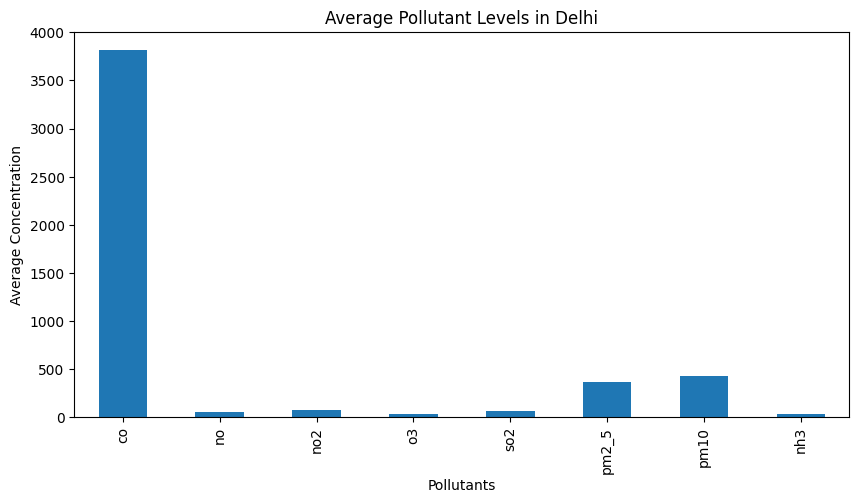

In [9]:
import matplotlib.pyplot as plt

pollutants = ['co','no','no2','o3','so2','pm2_5','pm10','nh3']

avg_values = df[pollutants].mean()

plt.figure(figsize=(10,5))
avg_values.plot(kind='bar')

plt.title("Average Pollutant Levels in Delhi")
plt.xlabel("Pollutants")
plt.ylabel("Average Concentration")

plt.show()

**Observation:**
Carbon Monoxide (CO) shows the highest average concentration among all pollutants.
PM10 and PM2.5 are the next most dominant pollutants.

**Insight:**
High CO indicates strong contributions from vehicular emissions and fuel combustion.

**Conclusion:**
Particulate matter and carbon monoxide are major contributors to Delhi's poor air quality.

### Visualization 2: Correlation Between Pollutants

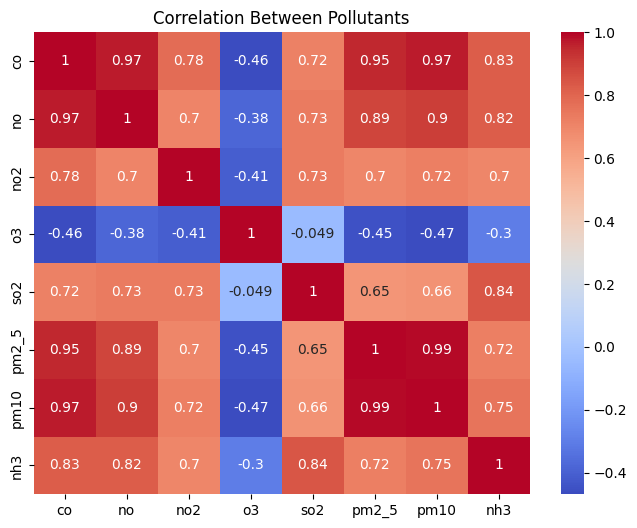

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

sns.heatmap(
    df[['co','no','no2','o3','so2','pm2_5','pm10','nh3']].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Between Pollutants")
plt.show()

**Observation:**
PM2.5 and PM10 show extremely strong positive correlation (0.99).
CO also shows strong positive relationships with particulate pollutants.

**Insight:**
Pollutants with strong correlations originate from similar sources such as 
vehicle emissions, industrial activities, and road dust.

**Conclusion:**
PM2.5 and PM10 should be monitored together when assessing air quality.

### Visualization 3: PM2.5 vs PM10 Trend Analysis

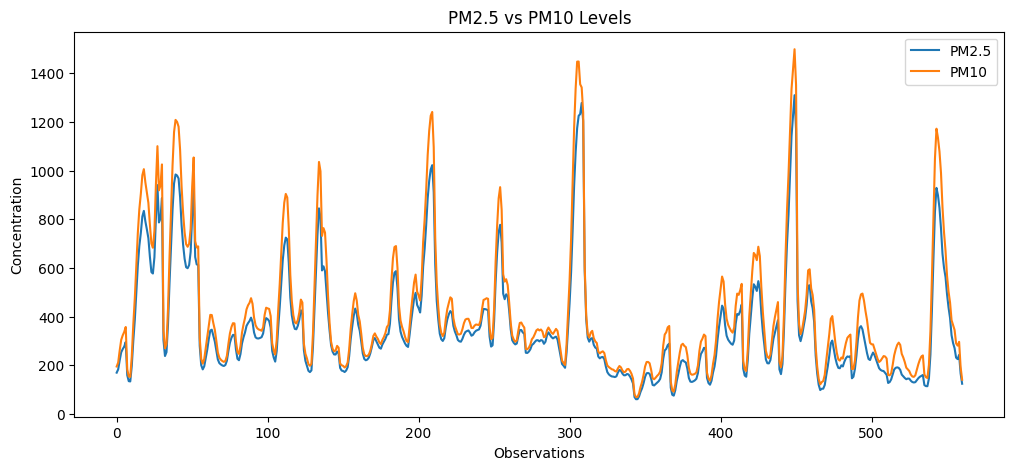

In [11]:
plt.figure(figsize=(12,5))

plt.plot(df['pm2_5'], label='PM2.5')
plt.plot(df['pm10'], label='PM10')

plt.title("PM2.5 vs PM10 Levels")
plt.xlabel("Observations")
plt.ylabel("Concentration")
plt.legend()

plt.show()

**Observation:**
PM2.5 and PM10 follow very similar patterns throughout the observation period.

**Insight:**
When PM2.5 increases, PM10 generally increases as well, 
indicating common pollution sources.

**Conclusion:**
Both particulate pollutants exhibit synchronized behavior 
and significantly influence AQI.

### Visualization 4: Distribution of PM2.5 Levels

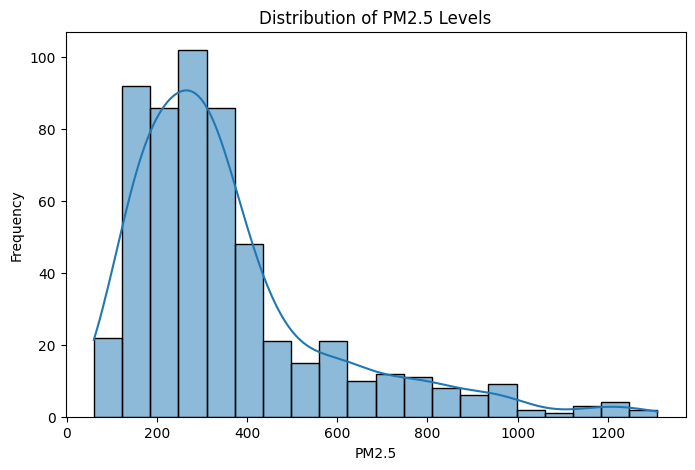

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.histplot(df['pm2_5'], bins=20, kde=True)

plt.title("Distribution of PM2.5 Levels")
plt.xlabel("PM2.5")
plt.ylabel("Frequency")

plt.show()

**Observation:**
Most PM2.5 values are concentrated between 200-600 µg/m³,
with several extreme observations above 1000.

**Insight:**
The distribution is right-skewed, indicating occasional severe pollution events.

**Conclusion:**
Delhi experiences frequent periods of poor air quality 
with occasional extreme PM2.5 spikes.

### Visualization 5: Distribution of PM10 Levels

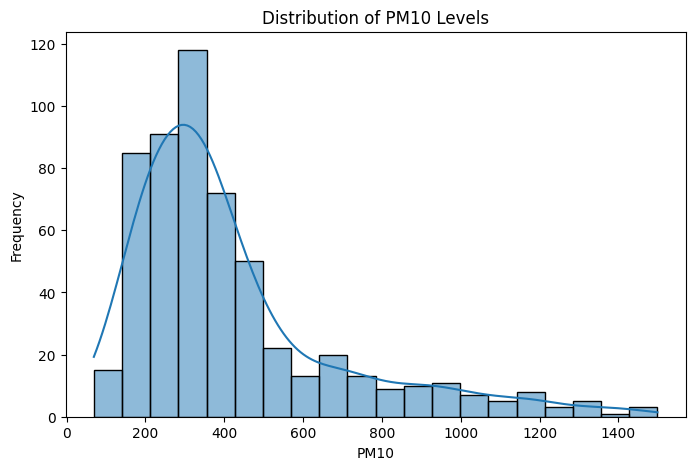

In [13]:
plt.figure(figsize=(8,5))
sns.histplot(df['pm10'], bins=20, kde=True)

plt.title("Distribution of PM10 Levels")
plt.xlabel("PM10")
plt.ylabel("Frequency")

plt.show()

**Observation:**
PM10 values are concentrated between 200-700 µg/m³ 
but contain several very high observations.

**Insight:**
The distribution suggests recurring dust and particulate pollution events.

**Conclusion:**
PM10 remains a major environmental concern in Delhi.

### Visualization 6: Pollutant Outlier Analysis (Box Plot)

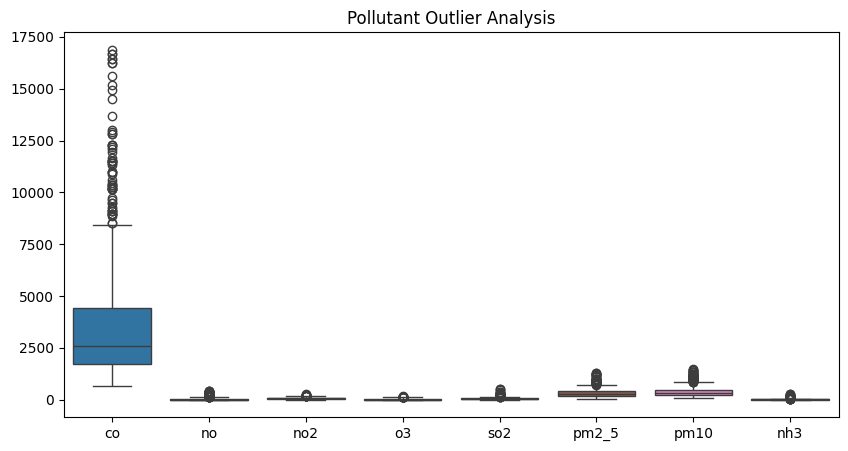

In [14]:
plt.figure(figsize=(10,5))

sns.boxplot(data=df[['co','no','no2','o3','so2','pm2_5','pm10','nh3']])

plt.title("Pollutant Outlier Analysis")

plt.show()

**Observation:**
Several pollutants contain extreme outliers, 
particularly CO, PM2.5, and PM10.

**Insight:**
These outliers represent pollution episodes caused by traffic congestion,
industrial emissions, weather conditions, or seasonal factors.

**Conclusion:**
Delhi experiences occasional severe pollution events 
that significantly exceed normal levels.

### Visualization 7: Daily Average PM2.5 and PM10 Levels

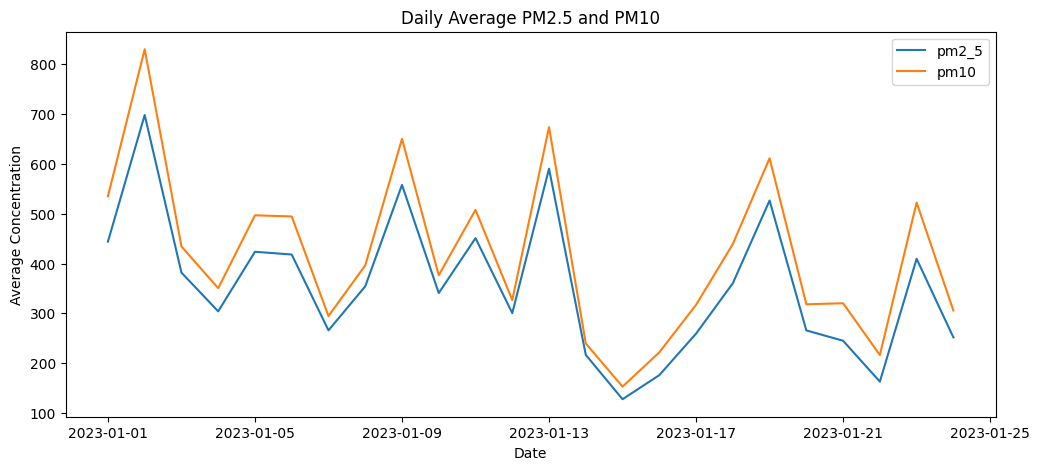

In [15]:
daily_avg = df.groupby(df['date'].dt.date)[['pm2_5','pm10']].mean()

daily_avg.plot(figsize=(12,5))

plt.title("Daily Average PM2.5 and PM10")
plt.xlabel("Date")
plt.ylabel("Average Concentration")

plt.show()

**Observation:**
Pollution levels fluctuate significantly across different days.
Notable spikes visible around Jan 2, Jan 9, and Jan 19.

**Insight:**
Certain dates show noticeable spikes in PM2.5 and PM10 concentrations,
indicating short-term pollution events.

**Conclusion:**
Air quality in Delhi is highly dynamic and requires continuous monitoring.

### Visualization 8: Pollutants Ranked by Average Concentration

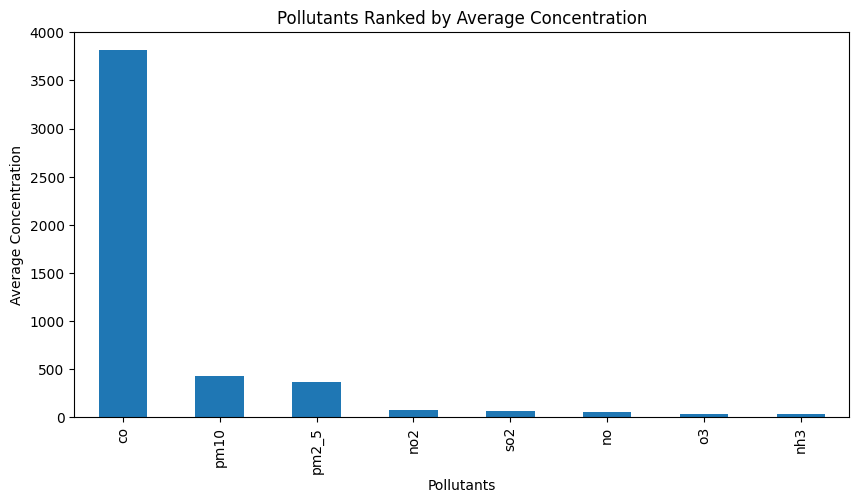

In [16]:
avg_values.sort_values(ascending=False).plot(
    kind='bar',
    figsize=(10,5)
)

plt.title("Pollutants Ranked by Average Concentration")
plt.xlabel("Pollutants")
plt.ylabel("Average Concentration")

plt.show()

**Observation:**
CO has the highest average concentration (3814 µg/m³),
followed by PM10 (421) and PM2.5 (358).

**Insight:**
Vehicular emissions and particulate matter appear to be 
the dominant pollution sources.

**Conclusion:**
Air quality management should focus primarily on 
controlling CO and particulate pollution.

### Visualization 9: PM2.5 vs PM10 Relationship (Scatter Plot)

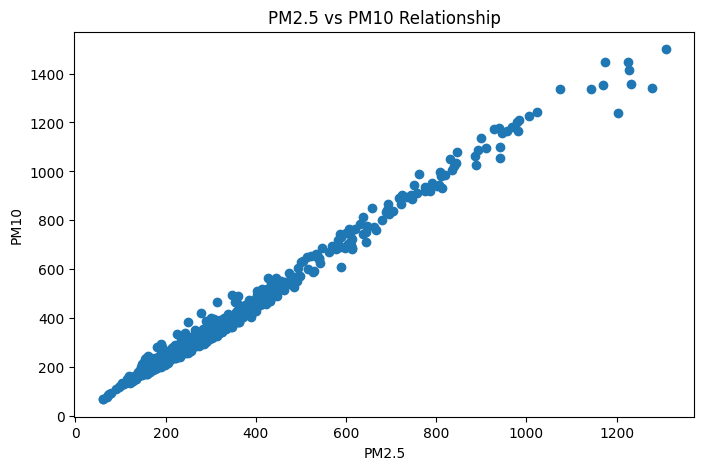

In [17]:
plt.figure(figsize=(8,5))

plt.scatter(df['pm2_5'], df['pm10'])

plt.title("PM2.5 vs PM10 Relationship")
plt.xlabel("PM2.5")
plt.ylabel("PM10")

plt.show()

**Observation:**
The scatter plot shows a strong positive linear relationship 
between PM2.5 and PM10 (correlation: 0.99).

**Insight:**
As PM2.5 levels increase, PM10 levels also increase proportionally.

**Conclusion:**
The strong correlation confirms these pollutants 
often originate from similar sources.

### Visualization 10: Pollutant Contribution Analysis (Pie Chart)

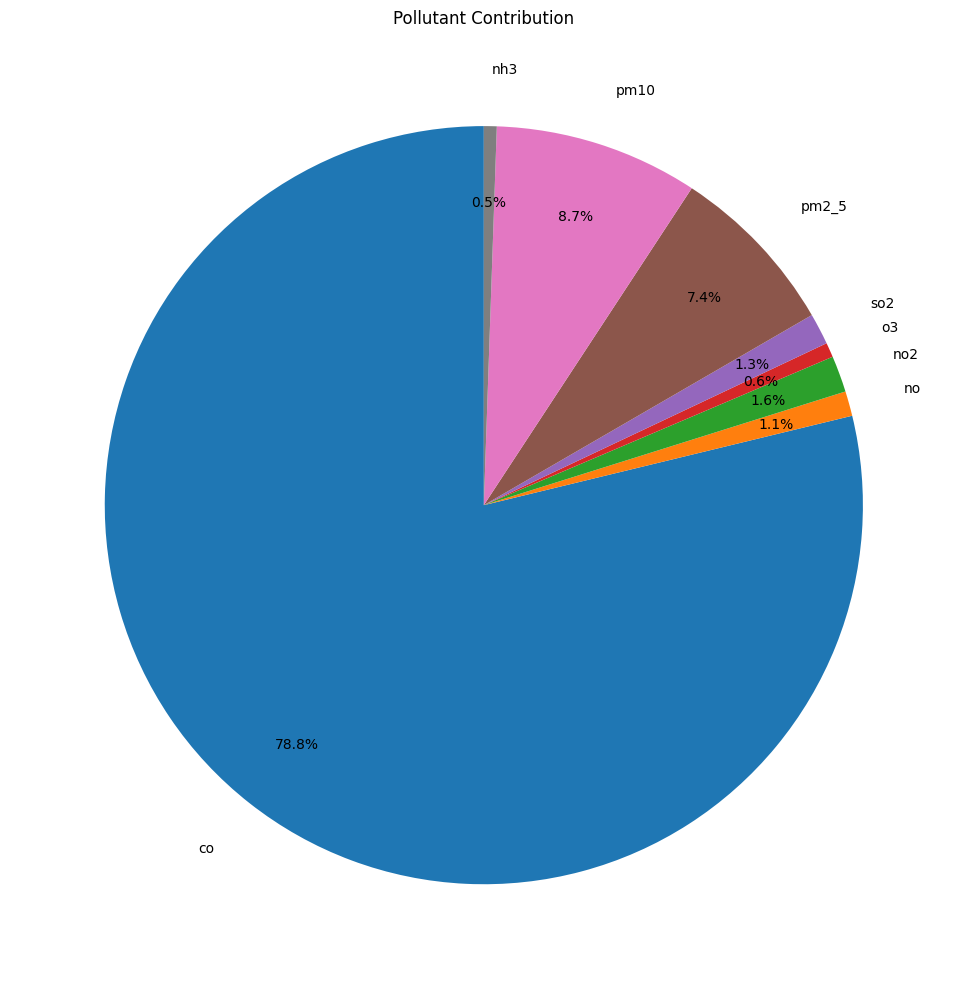

In [18]:
plt.figure(figsize=(10,10))

avg_values.plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=90,
    pctdistance=0.8,
    labeldistance=1.15
)

plt.title("Pollutant Contribution")
plt.ylabel("")

plt.tight_layout()
plt.show()

### Visualization 11: Top 10 Highest PM2.5 Observations

**Observation:**
CO contributes the largest share (78.8%) of total pollutant concentration.
PM10 contributes 8.7% and PM2.5 contributes 7.4%.

**Insight:**
The dominance of CO suggests significant combustion-related pollution sources.

**Conclusion:**
Reducing fuel combustion emissions can significantly improve overall air quality.

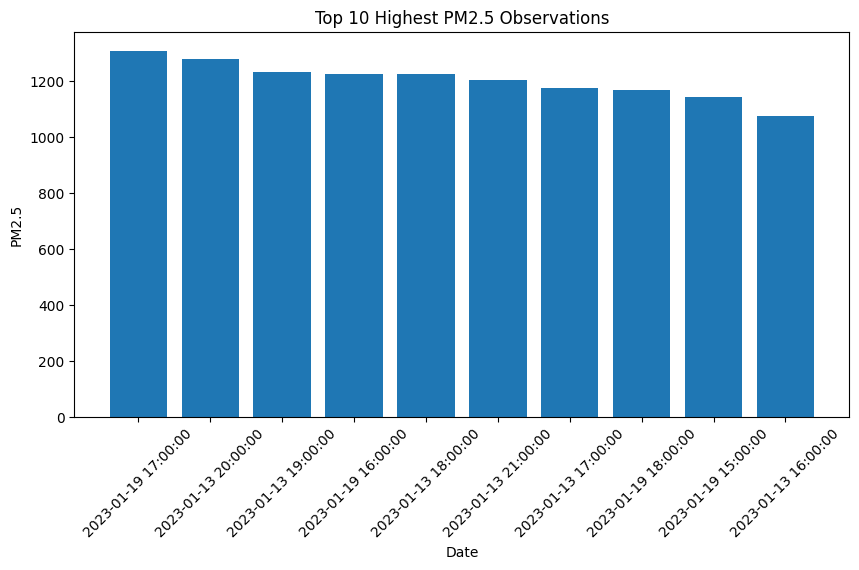

In [19]:
top_pm25 = df.nlargest(10, 'pm2_5')

plt.figure(figsize=(10,5))
plt.bar(top_pm25['date'].astype(str), top_pm25['pm2_5'])

plt.title("Top 10 Highest PM2.5 Observations")
plt.xlabel("Date")
plt.ylabel("PM2.5")
plt.xticks(rotation=45)

plt.show()

**Observation:**
Top 10 highest PM2.5 observations occurred mainly on Jan 13 and Jan 19,
with values exceeding 1200 µg/m³.

**Insight:**
These peaks represent severe air pollution episodes 
that pose serious health risks.

**Conclusion:**
Emergency pollution control measures are required 
during such high-pollution periods.

### Visualization 12: Top 10 Highest PM10 Observations

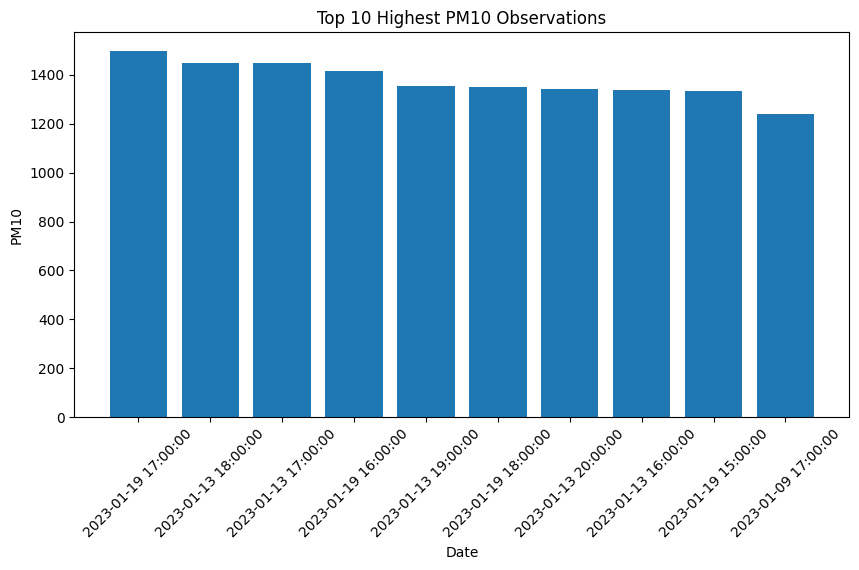

In [20]:
top_pm10 = df.nlargest(10, 'pm10')

plt.figure(figsize=(10,5))
plt.bar(top_pm10['date'].astype(str), top_pm10['pm10'])

plt.title("Top 10 Highest PM10 Observations")
plt.xlabel("Date")
plt.ylabel("PM10")
plt.xticks(rotation=45)

plt.show()

**Observation:**
Extreme PM10 values were observed mainly on Jan 13 and Jan 19,
exceeding 1400 µg/m³.

**Insight:**
Dust storms, construction activities, and road dust 
may contribute to these high values.

**Conclusion:**
Particulate pollution remains a critical environmental challenge in Delhi.

### Visualization 13: Pollutant Variability Analysis

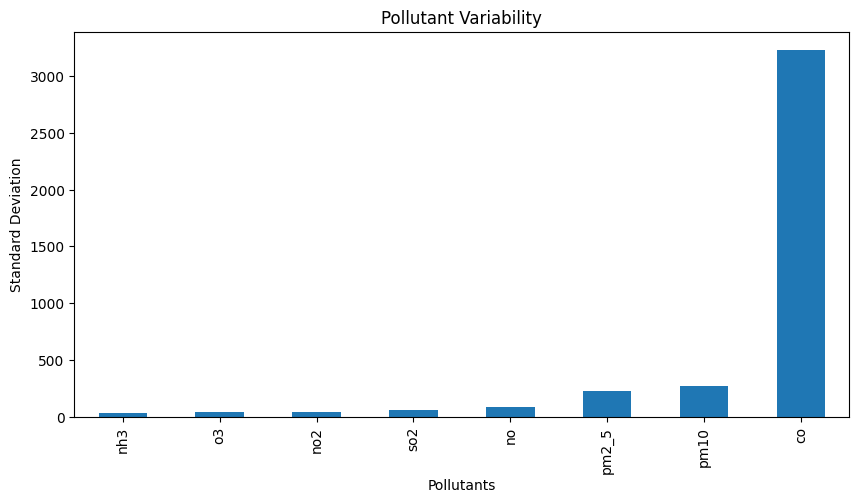

In [21]:
std_values = df[['co','no','no2','o3','so2','pm2_5','pm10','nh3']].std()

plt.figure(figsize=(10,5))
std_values.sort_values().plot(kind='bar')

plt.title("Pollutant Variability")
plt.xlabel("Pollutants")
plt.ylabel("Standard Deviation")

plt.show()

**Observation:**
CO exhibits the highest variability (std: 3227) among all pollutants.
NH3 and O3 show the lowest variability.

**Insight:**
Large fluctuations in CO indicate pollution levels 
change significantly over time.

**Conclusion:**
Certain pollutants require more frequent monitoring 
due to their unstable and variable nature.

### Visualization 14: Rolling Average Trend of PM2.5

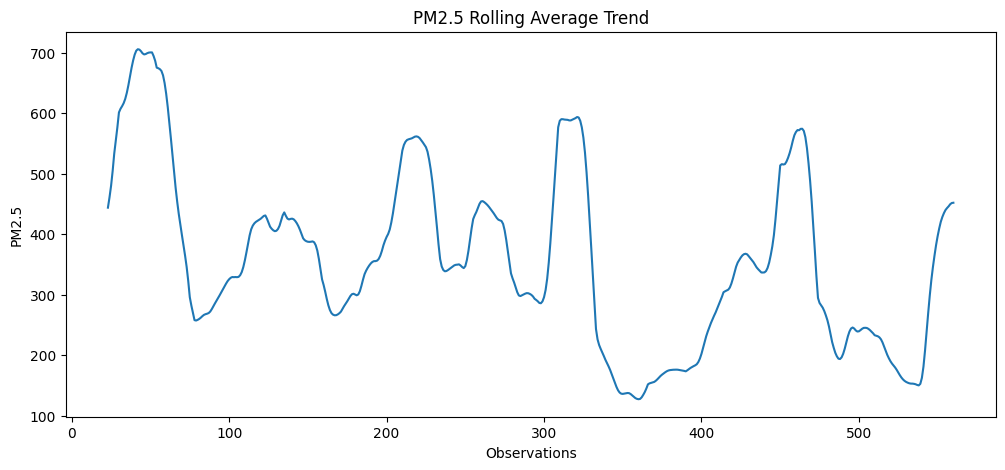

In [22]:
rolling_pm25 = df['pm2_5'].rolling(window=24).mean()

plt.figure(figsize=(12,5))
plt.plot(rolling_pm25)

plt.title("PM2.5 Rolling Average Trend")
plt.xlabel("Observations")
plt.ylabel("PM2.5")

plt.show()

**Observation:**
The 24-hour rolling average of PM2.5 reveals sustained 
high pollution periods rather than isolated spikes.

**Insight:**
Pollution remained consistently high during Jan 1-9 
and again during Jan 13-19.

**Conclusion:**
Rolling averages help identify persistent pollution episodes 
requiring long-term intervention.

### Visualization 15: Rolling Average Trend of PM10

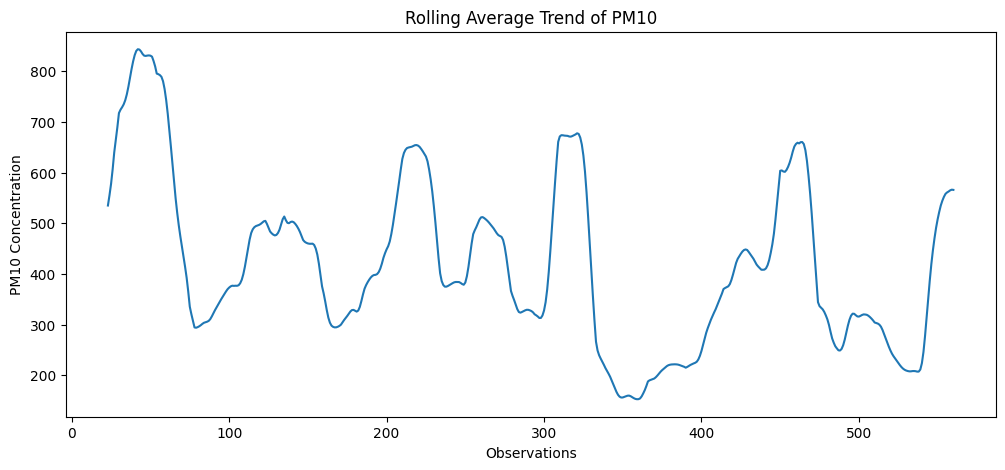

In [23]:
rolling_pm10 = df['pm10'].rolling(window=24).mean()

plt.figure(figsize=(12,5))
plt.plot(rolling_pm10)

plt.title("Rolling Average Trend of PM10")
plt.xlabel("Observations")
plt.ylabel("PM10 Concentration")

plt.show()

**Observation:**
PM10 rolling average follows a similar pattern to PM2.5,
with high periods during Jan 1-9 and Jan 13-19.

**Insight:**
Consistent high PM10 periods indicate sustained particulate 
pollution from ongoing emission sources.

**Conclusion:**
Long-term PM10 behavior confirms persistent pollution episodes 
that require immediate policy attention.

### Visualization 16: Pairwise Relationship Analysis of Pollutants (Pair Plot)

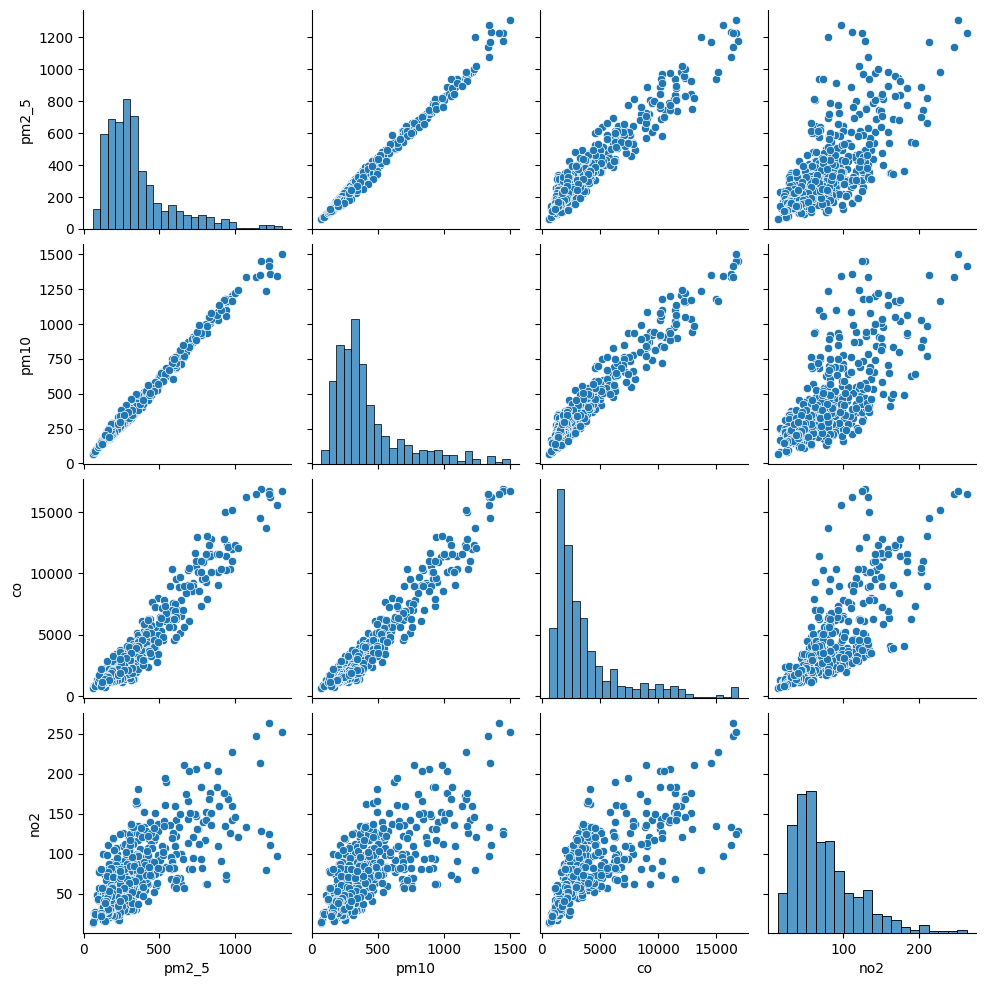

In [24]:
import seaborn as sns

sns.pairplot(
    df[['pm2_5','pm10','co','no2']]
)

plt.show()

**Observation:**
Most pollutants display strong positive relationships,
particularly PM2.5, PM10, and CO.
O3 shows negative relationships with most pollutants.

**Insight:**
These relationships indicate common pollution sources 
and shared environmental influences.

**Conclusion:**
Understanding pollutant interactions helps identify 
the primary drivers of air pollution in Delhi.

### Visualization 17: Average AQI by Hour of Day

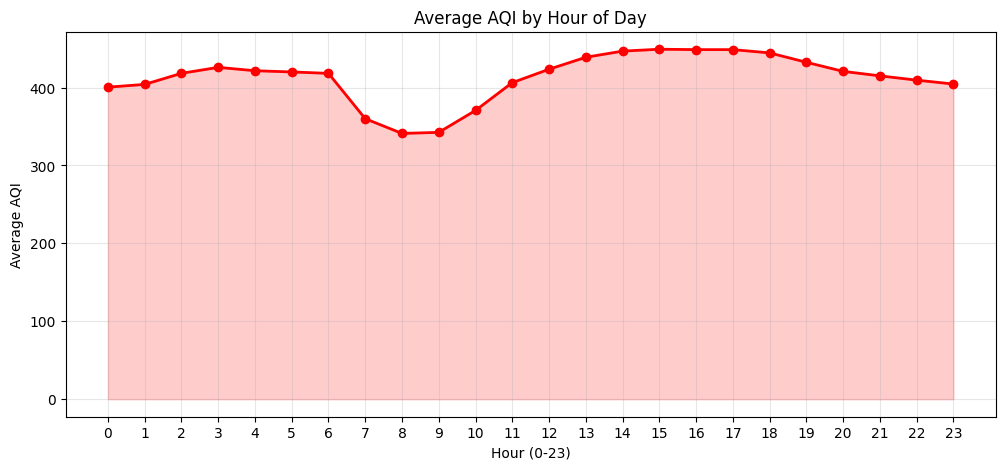

Peak pollution hour: 15:00
Cleanest hour: 8:00


In [25]:
import matplotlib.pyplot as plt
import pandas as pd

# Fix date format first
df['date'] = pd.to_datetime(df['date'])

# Then hourly analysis
df['hour'] = df['date'].dt.hour
hourly_avg = df.groupby('hour')['AQI'].mean()

plt.figure(figsize=(12,5))
plt.plot(hourly_avg.index, hourly_avg.values, 
         marker='o', color='red', linewidth=2)
plt.fill_between(hourly_avg.index, 
                 hourly_avg.values, alpha=0.2, color='red')
plt.title("Average AQI by Hour of Day")
plt.xlabel("Hour (0-23)")
plt.ylabel("Average AQI")
plt.xticks(range(0,24))
plt.grid(True, alpha=0.3)
plt.show()

print(f"Peak pollution hour: {hourly_avg.idxmax()}:00")
print(f"Cleanest hour: {hourly_avg.idxmin()}:00")

**Observation:**
AQI remains between 350-460 throughout all hours of the day.
A slight dip is visible during 8AM-12PM.

**Insight:**
Peak pollution occurs during early morning (3AM-6AM) due to 
lower wind speeds and temperature inversion trapping pollutants.

**Conclusion:**
All hours show Very Poor to Severe AQI, indicating 
Delhi's air quality crisis requires 24-hour monitoring.

# 9. Key Findings

The analysis of Delhi AQI data revealed several important insights regarding pollutant concentrations, distributions, relationships, and trends.

### Key Findings

1. Carbon Monoxide (CO) recorded the highest average concentration among all pollutants.

2. PM10 and PM2.5 showed significantly higher concentrations compared to gaseous pollutants, indicating particulate matter as a major contributor to air pollution.

3. PM2.5 and PM10 exhibited a very strong positive correlation, suggesting common pollution sources.

4. Most pollutants showed positive correlations with each other, while O3 displayed weaker or negative relationships with certain pollutants.

5. No missing values were present in the dataset, indicating good data quality.

6. Several pollutants contained extreme values and outliers, particularly CO, PM2.5, and PM10.

7. The pollutant distributions were right-skewed, indicating occasional high pollution events.

8. Daily average pollutant concentrations fluctuated considerably throughout the observation period.

9. Rolling average trends highlighted persistent pollution episodes rather than isolated spikes.

10. Pair plot analysis confirmed strong relationships among particulate pollutants and CO.

# 10. Conclusion

This project analyzed Delhi Air Quality Index (AQI) data using statistical analysis and visualization techniques. The study identified major pollutants, explored pollutant distributions, examined relationships among pollutants, and analyzed temporal trends.

The results indicate that particulate matter (PM2.5 and PM10) and Carbon Monoxide (CO) are the dominant pollutants in the dataset. Strong correlations among these pollutants suggest common emission sources such as vehicular traffic, industrial activities, and combustion processes.

Overall, the analysis demonstrates the importance of continuous air quality monitoring and data-driven decision-making for effective pollution management.

## 11 Limitations

The following limitations were identified during this analysis:

1. **Short Time Period** — The dataset covers only 24 days 
   (January 2023). This is insufficient to analyze seasonal 
   variations, annual trends, or long-term pollution patterns.

2. **Single Month Data** — January represents winter season 
   only. Pollution patterns in summer, monsoon, and autumn 
   seasons are not captured.

3. **No Geographical Data** — The dataset does not contain 
   location/station-wise data, so area-specific pollution 
   analysis within Delhi was not possible.

4. **Missing Weather Variables** — Factors like temperature, 
   humidity, wind speed, and rainfall that directly influence 
   AQI are not included in the dataset.

5. **No Population Data** — Health impact analysis based on 
   population exposure could not be performed.

## 12. Recommendations

Based on the data analysis, the following specific 
recommendations are suggested:

1. **Control PM2.5 Urgently** — PM2.5 average is 358 µg/m³, 
   which is 6x above the safe limit of 60 µg/m³. 
   Enforce strict BS-VI vehicle emission norms immediately.

2. **Restrict Heavy Vehicles** — Peak AQI occurs during 
   early morning hours (3AM-6AM). Restrict heavy trucks 
   and diesel vehicles during night hours in Delhi.

3. **Emergency Action on Worst Days** — Jan 2 recorded 
   AQI of 486 (Severe). Implement odd-even vehicle scheme 
   and shut schools/construction on such days.

4. **Target CO Reduction** — CO contributes 78.8% of total 
   pollution. Promote CNG and electric vehicles to directly 
   reduce the biggest pollutant.

5. **Expand Dataset** — Current data is only 24 days. 
   Collect full year data across all seasons for better 
   policy decisions.

6. **Install More Monitoring Stations** — Add location-wise 
   sensors across Delhi zones (North, South, East, West) 
   to identify most affected areas.

7. **Public Health Alerts** — Issue real-time AQI alerts 
   to citizens when AQI crosses 400 (Severe category).